# Impact on the severity of COVID-19 based on symptoms

In [23]:
# libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

RANDOM_STATE = 42

In [24]:
df = pd.read_csv("Covid Dataset.csv") # load dataset
df = df.replace({"Yes": 1, "No": 0}) # standardize (yes/no to 1/0)
df.columns = df.columns.str.strip() # clean column names (removes spaces issues)

TARGET = "COVID-19" # identify target column 

# split features/target
X = df.drop(columns = [TARGET])
y = df[TARGET]

df.head()

C:\Users\sassy\AppData\Local\Temp\ipykernel_1056\2174684885.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({"Yes": 1, "No": 0}) # standardize (yes/no to 1/0)


,Breathing Problem,Fever,Dry Cough,Sore throat,Running Nose,Asthma,Chronic Lung Disease,Headache,Heart Disease,Diabetes,...,Fatigue,Gastrointestinal,Abroad travel,Contact with COVID Patient,Attended Large Gathering,Visited Public Exposed Places,Family working in Public Exposed Places,Wearing Masks,Sanitization from Market,COVID-19
0,1,1,1,1,1,0,0,0,0,1,...,1,1,0,1,0,1,1,0,0,1
1,1,1,1,1,0,1,1,1,0,0,...,1,0,0,0,1,1,0,0,0,1
2,1,1,1,1,1,1,1,1,0,1,...,1,1,1,0,0,0,0,0,0,1
3,1,1,1,0,0,1,0,0,1,1,...,0,0,1,0,1,1,0,0,0,1
4,1,1,1,1,1,0,1,1,1,1,...,0,1,0,1,0,1,0,0,0,1


In [25]:
# train/test split 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    random_state = 42,
                                                    stratify = y 
                                                    )

## XGBoost Model

In [26]:
model = XGBClassifier(n_estimators = 100,
                      max_depth = 3,
                      learning_rate = 0.05,
                      random_state = RANDOM_STATE,
                      use_label_encoder = False,
                      eval_metric = "logloss"
                      )

model.fit(X_train, y_train)

C:\Users\sassy\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:05:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
y_pred = model.predict(X_test) # predictions
accuracy = accuracy_score(y_test, y_pred) # metrics

print(f"Accuracy: {accuracy:.3f}\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.971

              precision    recall  f1-score   support

           0       0.97      0.88      0.92       210
           1       0.97      0.99      0.98       877

    accuracy                           0.97      1087
   macro avg       0.97      0.93      0.95      1087
weighted avg       0.97      0.97      0.97      1087



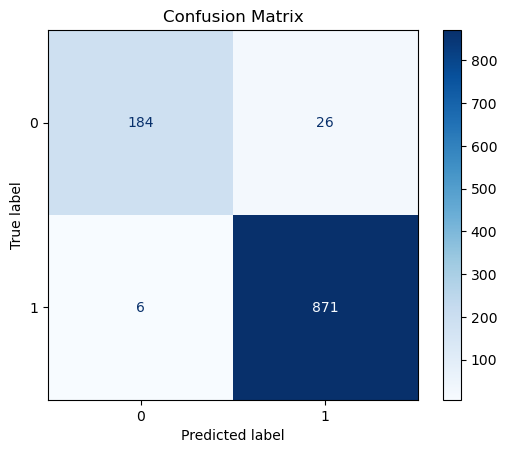

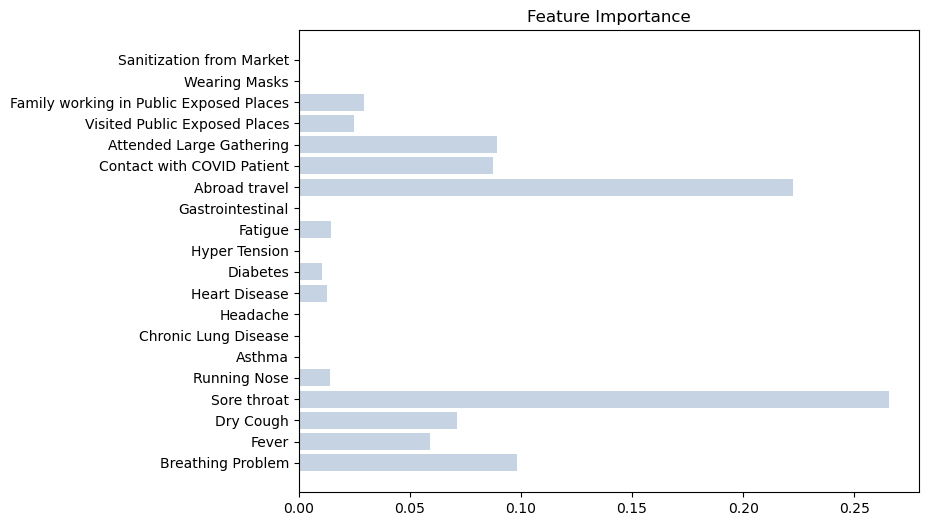

In [28]:
# confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,
                                        y_pred,
                                        cmap = "Blues" 
                                        )
plt.title("Confusion Matrix")
plt.show()

# feature importance
plt.figure(figsize = (8, 6))
plt.barh(X.columns, model.feature_importances_, color = "#c6d3e3")
plt.title("Feature Importance")
plt.show()

## Decision Tree Model

In [31]:
dt_model = DecisionTreeClassifier(max_depth = 5,
                                  random_state = 42
                                  )

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [32]:
dt_pred = dt_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.3f}\n")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.963

              precision    recall  f1-score   support

           0       1.00      0.81      0.89       210
           1       0.96      1.00      0.98       877

    accuracy                           0.96      1087
   macro avg       0.98      0.90      0.94      1087
weighted avg       0.96      0.96      0.96      1087



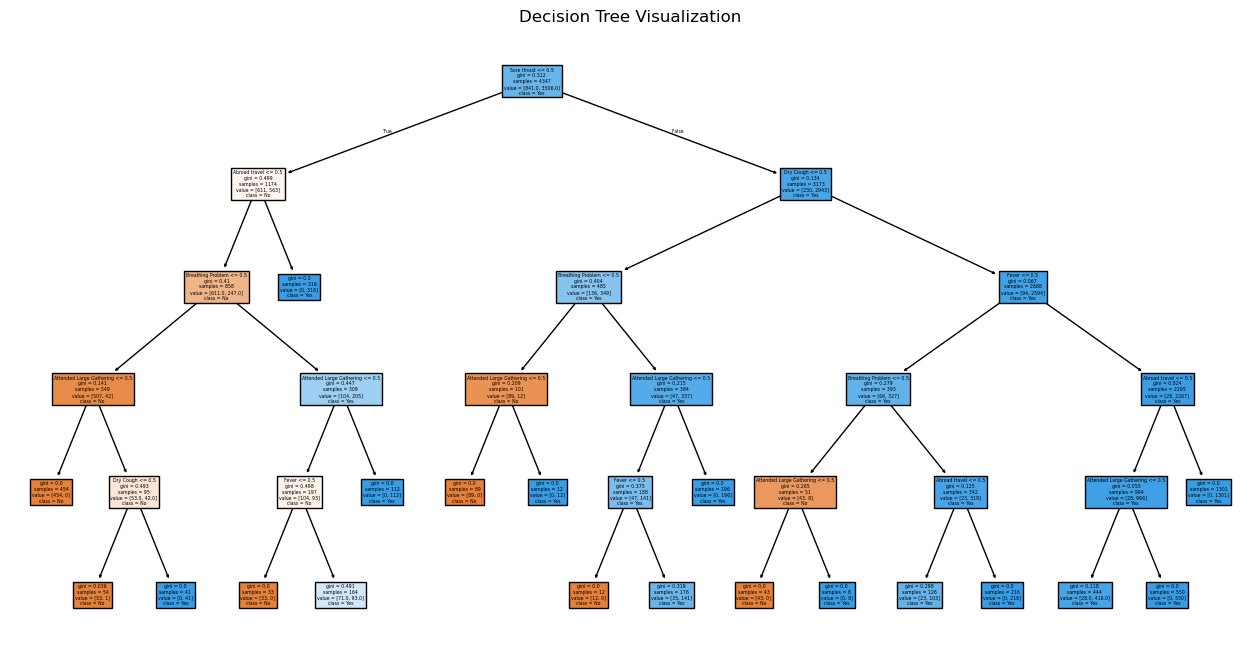

In [33]:
plt.figure(figsize = (16, 8))
plot_tree(dt_model,
          feature_names = X.columns,
          class_names = ["No", "Yes"],
          filled = True
          )
plt.title("Decision Tree Visualization")
plt.show()

In [34]:
print(f"""
Model Comparison:
- Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.3f}
- XGBoost Accuracy: {accuracy_score(y_test, y_pred):.3f}
""")


Model Comparison:
- Decision Tree Accuracy: 0.963
- XGBoost Accuracy: 0.971

